# Block 2: Temporal Alignment and Label Ambiguity
### Temporally Entangled Documents DocEng '26 Tutorial

This is the block built around this tutorial's own Figure 1: asynchronous evidence, an uncertain onset, and what it actually takes to align them. Three specific techniques, event-centred windowing, probabilistic labelling under onset uncertainty, and structured missingness, are what "temporal document engineering" means in code, not just in a diagram. You'll use all three by hand on real patient data before you ever train a model.

Then, because the payoff matters as much as the mechanics: we'll train the *obvious* approach, the one that skips all three, and watch it look excellent while quietly leaning on something that has nothing to do with physiology. Catching that, and fixing it architecturally, is what proves the alignment techniques weren't academic.

**Run it, watch it, break it, fix it.** Every number below is computed live from data you've already met.

## Setup

In [57]:
!rm -rf doceng26-pulse-and-paper
!git clone -q https://github.com/lbutler2405/doceng26-pulse-and-paper.git
REPO_ROOT = "/content/doceng26-pulse-and-paper"
DATA_DIR = f"{REPO_ROOT}/data"

%pip install -q reportlab

import sys
sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss

import alignment as al
import models as m

TEAL, SEAFOAM, MINT, DARK, MUTED, CORAL, AMBER = (
    "#028090", "#00A896", "#02C39A", "#0A2E36", "#6B7C7E", "#D96C6C", "#E1A82D")

print("Ready.")
print("Predicting: will this patient deteriorate at some point during their stay?")
print(f"Every prediction below is made {m.PREDICTION_OFFSET_HOURS} hours after the (model-unknown) onset point for")
print("patients who deteriorate, and at an equally-plausible matched snapshot for patients who don't.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.6 MB/s eta 0:00:00
Ready.
Predicting: will this patient deteriorate at some point during their stay?
Every prediction below is made 6.0 hours after the (model-unknown) onset point for
patients who deteriorate, and at an equally-plausible matched snapshot for patients who don't.


## Three things a naive pipeline gets wrong

A standard multimodal pipeline treats a clinical record as a static, synchronous input: pool everything available, hand it to a model, done. That single move breaks in three specific, fixable ways for data like this, and each one has a real function in `alignment.py` behind it, not just a name:

1. **Event-centred windowing.** A snapshot value ("last heart rate = 117") throws away the shape of what's happening. A trend, is it rising, falling, flat, doesn't.
2. **Onset uncertainty and soft labelling.** Deterioration isn't a light switch. It's somewhere in a window, the same `possible_window_start` / `possible_window_end` you met in Block 1. Treating it as a hard 0/1 at an arbitrary cut throws that uncertainty away.
3. **Structured missingness.** A window with 9 readings and a window with 192 readings are not the same evidence, but a naive pipeline that only looks at the *values* it found can't tell the difference.

Let's do all three by hand, on real patients, before any model gets involved.

### 1. Event-centred windowing

`alignment.naive_window()` grabs everything in a lookback period, that part's unavoidable, everyone has to pick a window. The difference is what you do with it once you have it. `alignment.event_centered_trend()` returns the last value *and* a fitted slope, "rising at 0.4 bpm/hour" is a different fact than "was 117," even when the last value is identical.

In [58]:
patients, vitals, labs, notes, labels = m._load(DATA_DIR)
labels["possible_window_start"] = pd.to_datetime(labels["possible_window_start"])
labels["possible_window_end"] = pd.to_datetime(labels["possible_window_end"])
pred_times = m._prediction_times(patients, labels)

print(f"Loaded {len(patients)} patients, {len(vitals):,} vitals readings, "
      f"{len(labs):,} lab results, {len(notes)} notes.")
print(f"Computed a prediction time for each of the {len(pred_times)} patients, "
      f"the same rule for everyone: {m.PREDICTION_OFFSET_HOURS}h after onset "
      f"(or an equally-plausible snapshot, for patients who never deteriorate).")

Loaded 75 patients, 12,176 vitals readings, 2,116 lab results, 385 notes.
Computed a prediction time for each of the 75 patients, the same rule for everyone: 6.0h after onset (or an equally-plausible snapshot, for patients who never deteriorate).


In [59]:
patient_id = 90000003  # has a real deterioration event, good for this walkthrough
pred_time = pred_times[patient_id]
pv = vitals[vitals.subject_id == patient_id]

window = al.naive_window(pv, "charttime", pred_time, 48).dropna(subset=["heartrate"])
last, slope, n = al.event_centered_trend(pv, "charttime", "heartrate", pred_time, 48)

print(f"Patient {patient_id}, prediction time: {pred_time}")
print(f"{n} heart rate readings in the 48h lookback window")
print(f"Last value: {last:.1f} bpm  |  Trend slope: {slope:+.2f} bpm/hr")

Patient 90000003, prediction time: 2024-04-04 03:58:00
164 heart rate readings in the 48h lookback window
Last value: 116.6 bpm  |  Trend slope: +0.41 bpm/hr


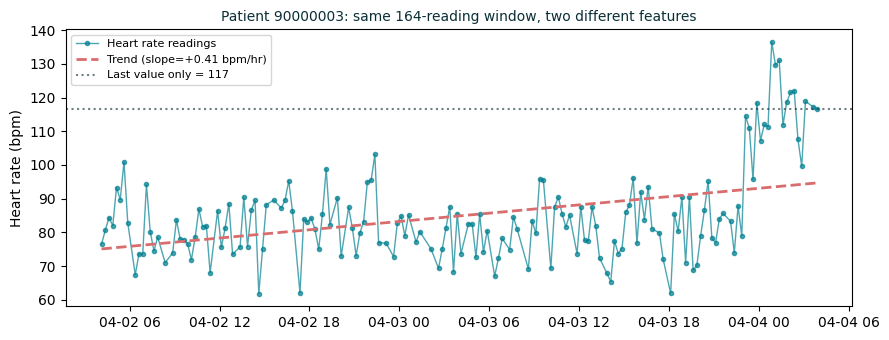

In [60]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(window.charttime, window.heartrate, "o-", color=TEAL, markersize=3, linewidth=1, alpha=0.7, label="Heart rate readings")
t0 = window.charttime.min()
hours = (window.charttime - t0).dt.total_seconds() / 3600
fit = np.polyfit(hours, window.heartrate, 1)
ax.plot(window.charttime, np.polyval(fit, hours), "--", color=CORAL, linewidth=2, label=f"Trend (slope={slope:+.2f} bpm/hr)")
ax.axhline(last, color=DARK, linestyle=":", alpha=0.6, label=f"Last value only = {last:.0f}")
ax.legend(fontsize=8, loc="upper left")
ax.set_title(f"Patient {patient_id}: same {n}-reading window, two different features", fontsize=10, color=DARK)
ax.set_ylabel("Heart rate (bpm)")
fig.tight_layout()
plt.show()

Same data, same window. "Last value only" is a flat dotted line, it can't distinguish a patient who's been stable at 117 all along from one who just spiked there. The trend line can. That distinction is the entire reason `event_centered_trend` returns three numbers instead of one.

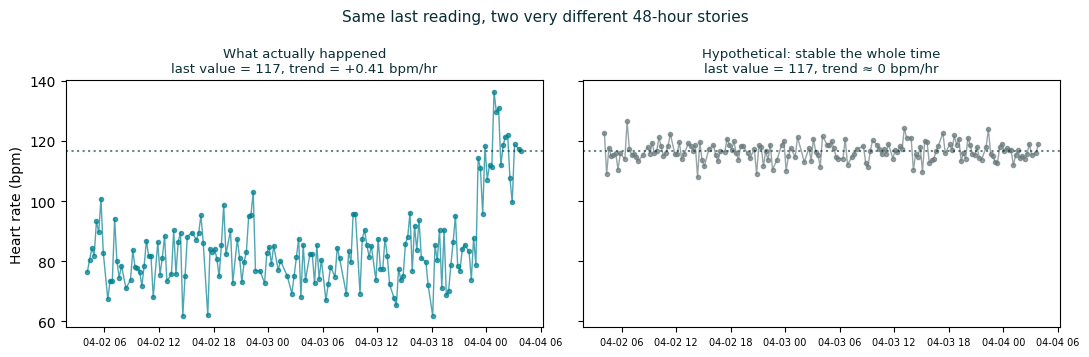

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)

ax = axes[0]
ax.plot(window.charttime, window.heartrate, "o-", color=TEAL, markersize=3, linewidth=1, alpha=0.7)
ax.axhline(last, color=DARK, linestyle=":", alpha=0.6)
ax.set_title(f"What actually happened\nlast value = {last:.0f}, trend = {slope:+.2f} bpm/hr", fontsize=9.5, color=DARK)
ax.set_ylabel("Heart rate (bpm)")
ax.tick_params(axis="x", labelsize=7)

# clearly-labeled hypothetical, not real data, illustrating the same last value
rng = np.random.default_rng(3)
hyp = last + rng.normal(0, 3, len(window))
ax = axes[1]
ax.plot(window.charttime, hyp, "o-", color=MUTED, markersize=3, linewidth=1, alpha=0.7)
ax.axhline(last, color=DARK, linestyle=":", alpha=0.6)
ax.set_title(f"Hypothetical: stable the whole time\nlast value = {last:.0f}, trend \u2248 0 bpm/hr", fontsize=9.5, color=DARK)
ax.tick_params(axis="x", labelsize=7)

fig.suptitle("Same last reading, two very different 48-hour stories", fontsize=11, color=DARK)
fig.tight_layout()
plt.show()

Left: what actually happened. Right: a hypothetical, clearly labeled as one, not a second real patient, showing what this same last reading would look like if it had been the truth the whole time instead of the end of a climb. Same dotted reference line in both panels, same ending value, and the 48 hours underneath it couldn't tell a more different story.

That's the entire argument for why `event_centered_trend` returns three numbers instead of one. A snapshot can't tell these two patients apart, both hand you "117." A trend can: `+0.41 bpm/hr` on the left, roughly flat on the right, and that one number is the difference between "this patient has been stable" and "this patient is climbing."

### 2. Onset uncertainty and soft, probabilistic labels

You met `possible_window_start` and `possible_window_end` in Block 1, the evidence-based estimate of when deterioration began, because the record never states it directly. Most pipelines pick one instant from that window (usually the midpoint, or the first note that mentions it) and train against a hard 0/1 label. `alignment.soft_event_label()` does something more honest: 0 before the window, ramping linearly across it, 1 after. It's not "when did it happen", it's "how confident should a label be, at this exact query time."

In [62]:
event_patients = labels[labels.outcome == 1].subject_id.tolist()
label_patient_id = patient_id if patient_id in event_patients else event_patients[0]
lrow = labels.set_index("subject_id").loc[label_patient_id]

print(f"Patient {label_patient_id}")
print(f"  Possible window: {lrow.possible_window_start} to {lrow.possible_window_end}")
print(f"  True onset (never shown to the model): {lrow.true_onset_time}")

Patient 90000003
  Possible window: 2024-04-03 21:43:00 to 2024-04-03 22:13:00
  True onset (never shown to the model): 2024-04-03 21:58:00


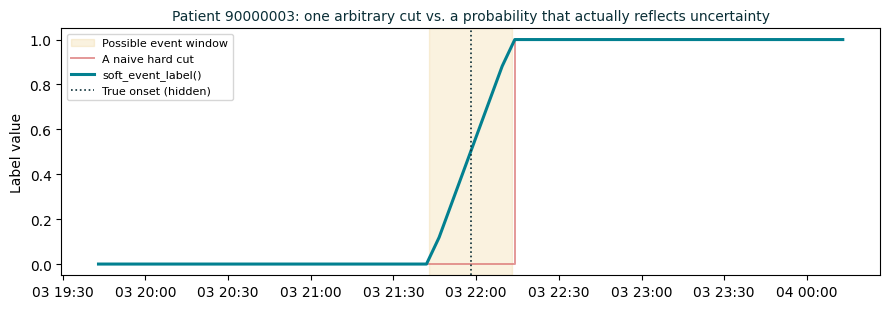

In [63]:
query_times = pd.date_range(lrow.possible_window_start - pd.Timedelta(hours=2),
                             lrow.possible_window_end + pd.Timedelta(hours=2), periods=60)
soft_labels = [al.soft_event_label(t, lrow.possible_window_start, lrow.possible_window_end) for t in query_times]
hard_labels = [0.0 if t < lrow.possible_window_end else 1.0 for t in query_times]  # the naive alternative: one arbitrary cut

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axvspan(lrow.possible_window_start, lrow.possible_window_end, color=AMBER, alpha=0.15, label="Possible event window")
ax.step(query_times, hard_labels, color=CORAL, linewidth=1.4, alpha=0.7, where="post", label="A naive hard cut")
ax.plot(query_times, soft_labels, color=TEAL, linewidth=2.2, label="soft_event_label()")
ax.axvline(lrow.true_onset_time, color=DARK, linestyle=":", linewidth=1.2, label="True onset (hidden)")
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("Label value")
ax.legend(fontsize=8, loc="upper left")
ax.set_title(f"Patient {label_patient_id}: one arbitrary cut vs. a probability that actually reflects uncertainty", fontsize=10, color=DARK)
fig.tight_layout()
plt.show()

Look at where the two lines disagree most, right inside the window itself. The hard cut is confidently wrong on one side of it no matter where you draw it. The soft label is honestly unsure exactly where the record is honestly unsure, and only that. This function exists in `alignment.py`, it's used nowhere in this pipeline's actual training yet, that's a deliberate "your turn" further down: try training the aware model against soft labels instead of the hard `outcome` column and see what changes.

### 3. Structured missingness

Two patients, two entanglement tiers, same lookback window, same code.

Patient 90000003 (tier=low): 192 vitals readings in a 48h window, completeness ratio = 2.00 (1.0 = as expected)
Patient 90000001 (tier=high): 9 vitals readings in a 48h window, completeness ratio = 0.09 (1.0 = as expected)


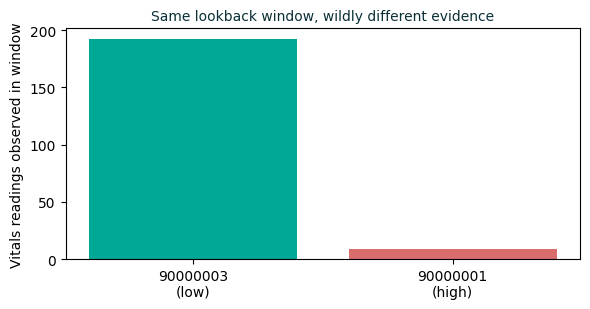

In [64]:
tiers = labels.set_index("subject_id").entanglement_tier
low_sid = tiers[tiers == "low"].index[0]
high_sid = tiers[tiers == "high"].index[0]

rows = []
for sid2 in [low_sid, high_sid]:
    pv2 = vitals[vitals.subject_id == sid2]
    n_obs, ratio = al.missingness_features(pv2, "charttime", pred_times[sid2], 48, expected_per_day=24*60/30)
    rows.append((sid2, tiers[sid2], n_obs, ratio))
    print(f"Patient {sid2} (tier={tiers[sid2]}): {n_obs} vitals readings in a 48h window, "
          f"completeness ratio = {ratio:.2f} (1.0 = as expected)")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar([f"{r[0]}\n({r[1]})" for r in rows], [r[2] for r in rows], color=[SEAFOAM, CORAL])
ax.set_ylabel("Vitals readings observed in window")
ax.set_title("Same lookback window, wildly different evidence", fontsize=10, color=DARK)
fig.tight_layout()
plt.show()

A naive pipeline that just averages "the values it found" treats these two patients identically once it has *a* number. But one of those numbers is built on 192 readings and the other on 9. Silence isn't neutral here, it's Part 4's whole argument again, now sitting inside a missingness ratio instead of a documentation lag. `missingness_features()` is what makes that ratio a feature the model can actually see, instead of a fact that quietly vanishes at the imputation step.

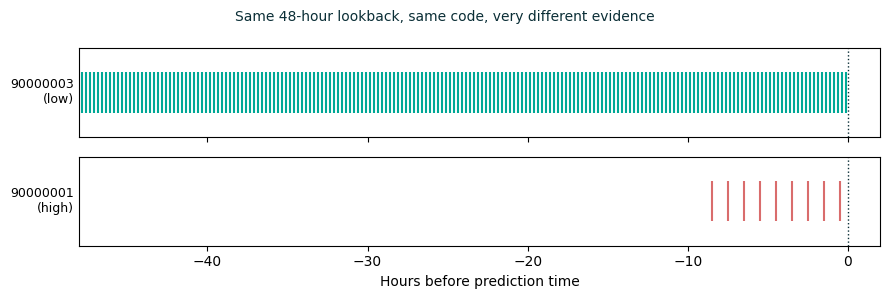

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(9, 3), sharex=True)
for ax, sid2, color in zip(axes, [low_sid, high_sid], [SEAFOAM, CORAL]):
    pv2 = vitals[vitals.subject_id == sid2]
    pred_time = pred_times[sid2]
    window = al.naive_window(pv2, "charttime", pred_time, 48)
    hours_before = (window.charttime - pred_time).dt.total_seconds() / 3600
    ax.eventplot(hours_before, lineoffsets=0, linelengths=0.8, color=color)
    ax.axvline(0, color=DARK, linewidth=1, linestyle=":")
    ax.set_xlim(-48, 2)
    ax.set_yticks([])
    ax.set_ylabel(f"{sid2}\n({tiers[sid2]})", rotation=0, ha="right", va="center", fontsize=9)
axes[-1].set_xlabel("Hours before prediction time")
fig.suptitle("Same 48-hour lookback, same code, very different evidence", fontsize=10, color=DARK)
fig.tight_layout()
plt.show()

The bar chart from before told you *how much* evidence each patient has, 192 readings versus 9. This tells you *where* it is. Patient 90000003's row is a solid wall, readings essentially back to back across the entire 48-hour window. Patient 90000001's row is empty for the first 39.5 hours, then a short cluster of readings in the last 8.5 hours before the prediction is made.

That's not "less monitoring, spread thin." It's a specific, nameable pattern: no evidence at all for most of the lookback window, then a burst right before the model has to make its call. `missingness_features()` collapses this into one completeness ratio (0.09 versus 2.00), which is the right number for a model to consume, but the ratio alone can't tell you *this* story, only the timeline can. Worth remembering the next time a completeness number looks low: it might mean sparse-but-even coverage, or it might mean this, nothing, then a burst, and those two patients need very different clinical interpretations even when their ratio looks similar.

## Now watch a pipeline that skips all three

Same rule for everyone on prediction timing, no cheating there, see the print statement back in Setup. What differs is everything downstream of it.

## Meet the model

Every model trained in this block, naive, shortcut, and time-aware alike, is the exact same three-step pipeline, defined once in `models.py`. Worth seeing it directly rather than taking "the model" on faith the first time `m.train_and_predict()` gets called below.

In [66]:
pipe = m.make_pipeline()
print(pipe)

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000))])


Three steps, in order, every single time this pipeline gets built:

1. **Impute.** A patient missing a lab value doesn't get dropped, they get the corpus's median for that feature. Simple, and honest about its own simplicity, this is the naive baseline's job to be genuinely naive here too.
2. **Scale.** Every feature gets standardized (mean 0, standard deviation 1) before the model ever sees it. This matters for a specific reason that comes back in Step 2: a coefficient is only comparable to another coefficient if the features attached to them are on the same scale. Skip this step and "biggest coefficient" stops meaning "most influential."
3. **Classify.** Logistic regression, not because it's the most powerful model available, on purpose. Every step in this block depends on being able to read the model's reasoning directly off its coefficients, not approximate it after the fact. That only works because logistic regression's coefficients *are* the actual computation.

`m.train_and_predict(X, y)` wraps one more step around this pipeline: a 70/30 train/test split, stratified so both sides keep roughly the same proportion of patients who actually deteriorated. At 75 patients total that's not a formality, an unstratified split could easily leave the test set with almost none.

In [67]:
naive_df, aware_df, meta_df = m.build_features(DATA_DIR)
y = meta_df["outcome"]
print(f"{len(naive_df)} patients total, {int(y.sum())} deteriorated ({y.mean():.0%})")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(naive_df, y, test_size=0.3, random_state=42, stratify=y)
print(f"Stratified 70/30 split: {len(X_train)} training patients ({int(y_train.sum())} positive), "
      f"{len(X_test)} test patients ({int(y_test.sum())} positive)")
print()
print("This exact split, same seed, same stratification, is what m.train_and_predict() repeats internally")
print("every time it's called below. Naive, shortcut, and time-aware models are all fit on the same 52")
print("patients and tested on the same 23, so every AUROC comparison in this block is apples to apples.")

75 patients total, 41 deteriorated (55%)
Stratified 70/30 split: 52 training patients (28 positive), 23 test patients (13 positive)

This exact split, same seed, same stratification, is what m.train_and_predict() repeats internally
every time it's called below. Naive, shortcut, and time-aware models are all fit on the same 52
patients and tested on the same 23, so every AUROC comparison in this block is apples to apples.


In [68]:
print("X_train: features only, no answer key. This is all the model ever sees during training.")
print(X_train.head(4))
print()
print("y_train: the answer key for those same patients, in the same order.")
print(y_train.head(4))
print()

print("The last column here is the outcome (y)")
preview = X_train.head(4).copy()
preview["outcome/ deterioration (y)"] = y_train.head(4)
preview

X_train: features only, no answer key. This is all the model ever sees during training.
            heartrate_last  o2sat_last  sbp_last  lactate_last  troponin_last  \
subject_id                                                                      
90000060             108.9        88.3     108.7          2.73            NaN   
90000050              84.5        98.5     106.9          0.88           0.00   
90000053             111.7        85.1      86.0          1.29           0.01   
90000017             110.8        83.1      87.9          0.56           0.01   

            n_labs  n_notes_naive  has_event_note_naive  \
subject_id                                                
90000060         4              1                     0   
90000050         8              2                     0   
90000053        16              1                     0   
90000017        24              3                     0   

            hours_since_last_note_naive  
subject_id                  

,heartrate_last,o2sat_last,sbp_last,lactate_last,troponin_last,n_labs,n_notes_naive,has_event_note_naive,hours_since_last_note_naive,outcome/ deterioration (y)
subject_id,,,,,,,,,,
90000060,108.9,88.3,108.7,2.73,NaN,4,1,0,7.716667,1
90000050,84.5,98.5,106.9,0.88,0.00,8,2,0,11.496705,0
90000053,111.7,85.1,86.0,1.29,0.01,16,1,0,36.800000,1
90000017,110.8,83.1,87.9,0.56,0.01,24,3,0,0.916667,1


Two things are being built above: `X` and `y`, the two ingredients every prediction model needs, and it's worth being explicit about which is which.

**`X` is what the model is allowed to look at.** In this notebook, `X` is `naive_df` (or `shortcut_df`, or `aware_df` later on), one row per patient, one column per *feature*, a single measurable fact the model gets to use. Look at the table `naive_df.head(3)` printed above: `heartrate_last`, `o2sat_last`, `n_labs`, `hours_since_last_note_naive`, each column is one feature. The model never sees a patient directly, it only ever sees these numbers.

**`y` is the answer key, the thing being predicted.** Here, `y = meta_df["outcome"]`, one number per patient: `1` if they deteriorated at some point during their stay, `0` if they didn't. During training, the model gets to see both `X` and `y` together, feature values *and* the correct answer, and adjusts itself to find the pattern connecting one to the other.

**Why split into train and test at all?** If you taught the model on all 75 patients and then quizzed it on those same 75 patients, a high score wouldn't prove much, it could just be memorizing rather than genuinely learning the pattern, the same way memorizing yesterday's quiz answers doesn't prove you understood the material. So the patients get split: `X_train`/`y_train` (52 patients) are what the model actually learns from, `X_test`/`y_test` (23 patients) are held back completely and only used afterward, to check whether whatever it learned generalizes to patients it has never seen. Every AUROC score in this notebook is computed on that held-out 23, never on the 52 the model was trained on.

**"Stratified"** just means the split was done carefully so both the 52 and the 23 end up with roughly the same proportion of patients who actually deteriorated, rather than leaving one group accidentally overloaded with positives and the other starved of them.

## Step 1: The obvious approach

Pool everything available by prediction time into a flat feature vector, last heart rate, last O2 sat, last blood pressure, last labs, and features almost anyone would reach for without thinking twice: how many notes exist so far, and is one of them flagging a concern. We are not considering trend in the current model fit, always taking the last value.

Notice what's missing compared to the three techniques above: no trend, just last values. No soft label, just the hard `outcome` column. No missingness feature, note count stands in for "how much evidence," which conflates volume with completeness. This is `alignment.naive_window()` and `alignment.naive_note_signal()` under the hood.

In [69]:
naive_df.head(8)

,heartrate_last,o2sat_last,sbp_last,lactate_last,troponin_last,n_labs,n_notes_naive,has_event_note_naive,hours_since_last_note_naive
subject_id,,,,,,,,,
90000001,88.3,96.9,124.4,0.83,0.01,4,1,0,0.542591
90000002,76.8,95.4,111.8,1.54,0.01,28,1,0,47.876431
90000003,116.6,83.7,94.3,2.00,0.77,20,3,1,1.483333
90000004,85.1,97.7,120.1,1.16,0.01,24,3,0,4.764389
90000005,81.6,95.9,120.2,1.35,0.01,40,2,0,17.353712
90000006,86.9,96.2,115.4,NaN,0.01,4,3,0,0.304406
90000007,69.5,99.4,138.5,NaN,0.02,4,1,0,10.204327
90000008,122.8,87.3,96.1,1.03,0.02,24,3,0,5.533333


In [70]:
pipe_naive, Xte_naive, yte_naive, proba_naive = m.train_and_predict(naive_df, y)
print(f"Naive model AUROC: {roc_auc_score(yte_naive, proba_naive):.3f}")
print(f"(same {len(Xte_naive)}-patient test set you just saw built above, this call just repeats the fit)")

Naive model AUROC: 1.000
(same 23-patient test set you just saw built above, this call just repeats the fit)


That's an excellent score. If this were the only number you looked at, you'd accept it.

## Step 2: Catch it cheating, part one, what did it actually learn?

A model's coefficients tell you what it's leaning on. Logistic regression makes this easy to read directly: a bigger coefficient (in either direction) means more influence on the prediction.

In [71]:
m.feature_importance(pipe_naive, naive_df.columns)

,0
o2sat_last,-1.536681
heartrate_last,1.352949
sbp_last,-0.754330
lactate_last,0.399973
has_event_note_naive,0.344008
troponin_last,0.246004
n_labs,0.172499
n_notes_naive,0.055546
hours_since_last_note_naive,-0.051856


Physiology dominates, as it should, `o2sat_last` and `heartrate_last` are doing most of the work. But look further down the list: **`has_event_note_naive` has real, positive weight.** The model didn't need to use "is there a worried-sounding note charted yet" to get the right answer today. It used it anyway, because in the training data, it happened to help.

This shows that this variable is present quietly inside the model's decision function, waiting for a situation where it matters more.

## Step 3: Catch it cheating, part two, isolate the shortcut

What if a model had *only* documentation timing to go on, no physiology at all? Let's actually build that model and see how far "how many notes, how recently" gets you on its own.

Same pipeline as Step 1, impute, scale, logistic regression, not a new model architecture, just a different, much smaller set of columns going into it.

In [72]:
shortcut_df = m.build_shortcut_features(DATA_DIR)
shortcut_df.head(8)

,n_notes_naive,has_event_note_naive,hours_since_last_note_naive
subject_id,,,
90000001,1,0,0.542591
90000002,1,0,47.876431
90000003,3,1,1.483333
90000004,3,0,4.764389
90000005,2,0,17.353712
90000006,3,0,0.304406
90000007,1,0,10.204327
90000008,3,0,5.533333


In [73]:
pipe_shortcut, Xte_shortcut, yte_shortcut, proba_shortcut = m.train_and_predict(shortcut_df, y)
print(f"Documentation-timing-only AUROC: {roc_auc_score(yte_shortcut, proba_shortcut):.3f}")

Documentation-timing-only AUROC: 0.562


It's abetter than a coin flip. Documentation timing genuinely does carry real signal on it's own, which is exactly why a naive pipeline finds it tempting. Now let's find out who that signal works for, and who it doesn't.

## Step 4: The reveal

Break that same shortcut-only model down by entanglement tier, the axis that controls how fast documentation happens, not by anything about the patient's actual physiology.

In [74]:
tier_recall = m.subgroup_recall(pipe_shortcut, shortcut_df, y, meta_df, "entanglement_tier")
tier_recall

,group,n_positive,recall,n_total
0,high,18,0.277778,31
1,low,15,0.600000,23
2,medium,8,0.875000,21


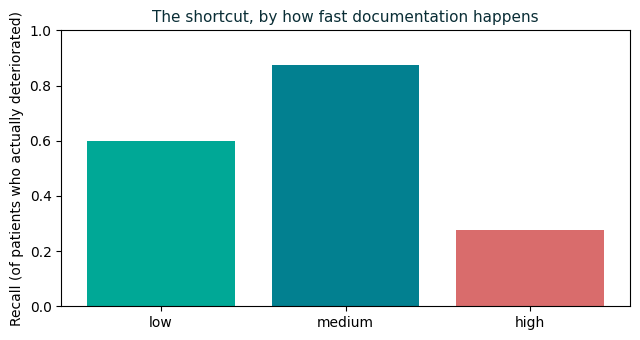

In [75]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
order = ["low", "medium", "high"]
vals = tier_recall.set_index("group").reindex(order)["recall"]
ax.bar(order, vals, color=[SEAFOAM, TEAL, CORAL])
ax.set_ylabel("Recall (of patients who actually deteriorated)")
ax.set_title("The shortcut, by how fast documentation happens", fontsize=11, color=DARK)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

The tier result could be read as expected, `entanglement_tier` is a difficulty axis this tutorial built specifically to control documentation speed, so of course a documentation-speed shortcut tracks it. The next cut is the one that actually matters: `population_context` describes who the patient is, dementia, disability, neurodivergent, none, not a synthetic knob this tutorial invented. If the same shortcut fails unevenly across these groups too, that's not an artifact of how this corpus was built, it's the shape of a real fairness problem: whichever patients take longer to get charted for real clinical or social reasons lose model performance for a reason that has nothing to do with their physiology.

In [76]:
ctx_recall = m.subgroup_recall(pipe_shortcut, shortcut_df, y, meta_df, "population_context")
ctx_recall.sort_values("recall")

,group,n_positive,recall,n_total
3,disability,3,0.000000,10
1,dementia_moderate,3,0.333333,6
4,neurodivergent,6,0.333333,9
5,none,21,0.571429,40
2,dementia_severe,4,0.750000,4
0,dementia_mild,4,0.750000,6


A model relying on documentation timing alone catches barely a quarter of true deterioration in the high-entanglement group, and does worst of all on exactly the patients Part 4 was about, disability and neurodivergent context here, small samples so treat the exact numbers as illustrative, but the direction is not noise, it's structural. **This is what "aggregate accuracy can hide exactly this" actually looks like, in code, not just as a line in a slide.**

The naive model in Step 1 didn't fail this badly overall, because physiology bailed it out. But it's still carrying a piece of this same bias inside it, quietly, at a smaller scale, exactly the coefficient you saw in Step 2.

## Step 5: The fix

Not "add more data" and not "tune harder." The fix is architectural, and it's exactly the two techniques from the top of this notebook, actually used this time: `event_centered_trend` in place of a snapshot, and `missingness_features` made explicit instead of silently dropped. Build a feature set that literally never gets the option to lean on documentation timing.

Still the exact same pipeline from "Meet the model", impute, scale, logistic regression, unchanged. Nothing about *how* the model learns is different here. What's different is what it's given the option to learn from, which is the entire point: the fix was never about a better model, it was about a better-engineered feature set.

Before training anything, look at what actually changed for one real patient, not in the abstract, in the numbers themselves.

In [77]:
print("naive_df row (last-value snapshots + the note-count shortcut):")
print(naive_df.loc[patient_id])
print()
print("aware_df row (trend + missingness, same patient):")
print(aware_df.loc[patient_id])

naive_df row (last-value snapshots + the note-count shortcut):
heartrate_last                 116.600000
o2sat_last                      83.700000
sbp_last                        94.300000
lactate_last                     2.000000
troponin_last                    0.770000
n_labs                          20.000000
n_notes_naive                    3.000000
has_event_note_naive             1.000000
hours_since_last_note_naive      1.483333
Name: 90000003, dtype: float64

aware_df row (trend + missingness, same patient):
heartrate_last         116.600000
heartrate_slope          0.409976
o2sat_last              83.700000
o2sat_slope             -0.123222
sbp_last                94.300000
sbp_slope               -0.268997
lactate_last             2.000000
lactate_slope            0.013270
troponin_last            0.770000
troponin_slope           0.015009
vitals_completeness      2.000000
labs_completeness        3.333333
Name: 90000003, dtype: float64


Look closely: `heartrate_last`, `o2sat_last`, `sbp_last`, every `_last` value is identical between the two rows, same patient, same underlying vitals, nothing about the physiology changed. What changed is exactly two things. First, every vitals and lab feature grew a `_slope` sibling, the trend from Section 1 at the top of this notebook, finally landing in the actual model. Second, `n_notes_naive`, `has_event_note_naive`, and `hours_since_last_note_naive` are gone entirely, replaced by `vitals_completeness` and `labs_completeness`, the structured-missingness features from Section 3. The model isn't getting less information. It's getting the *same* physiology, described more honestly, in place of a documentation-timing shortcut it was never supposed to need.

In [78]:
aware_df.head(8)

,heartrate_last,heartrate_slope,o2sat_last,o2sat_slope,sbp_last,sbp_slope,lactate_last,lactate_slope,troponin_last,troponin_slope,vitals_completeness,labs_completeness
subject_id,,,,,,,,,,,,
90000001,88.3,-0.037093,96.9,-0.022055,124.4,-0.364160,0.83,0.000000,0.01,0.000000,0.093750,0.666667
90000002,76.8,-0.070997,95.4,-0.001464,111.8,-0.050686,1.54,0.003086,0.01,0.000258,1.000000,4.666667
90000003,116.6,0.409976,83.7,-0.123222,94.3,-0.268997,2.00,0.013270,0.77,0.015009,2.000000,3.333333
90000004,85.1,0.051497,97.7,-0.000795,120.1,0.039556,1.16,-0.058210,0.01,-0.000161,1.000000,4.000000
90000005,81.6,0.043083,95.9,0.005427,120.2,0.200893,1.35,0.023830,0.01,-0.000071,2.000000,6.666667
90000006,86.9,0.374086,96.2,-0.008333,115.4,0.072453,NaN,NaN,0.01,0.000000,0.187500,0.666667
90000007,69.5,-0.720101,99.4,0.055025,138.5,-0.075377,NaN,NaN,0.02,0.000000,0.166667,0.666667
90000008,122.8,0.744382,87.3,-0.223392,96.1,-0.701345,1.03,0.015444,0.02,-0.000277,1.416667,4.000000


One more thing worth checking before training, and it's a different question from "are the shortcut columns present." They're not, you can see that above. The real question is whether the columns that *are* in `aware_df` somewhat correlate with documentation timing anyway, enough that the model could reconstruct the shortcut indirectly. This is checkable.

In [79]:
merged = aware_df.join(shortcut_df, how="inner")
corr = merged.corr()
leak_check = corr.loc[aware_df.columns, shortcut_df.columns]
leak_check.round(2)

,n_notes_naive,has_event_note_naive,hours_since_last_note_naive
heartrate_last,0.17,0.35,-0.14
heartrate_slope,0.02,0.27,-0.28
o2sat_last,-0.15,-0.39,0.09
o2sat_slope,-0.02,-0.29,0.28
sbp_last,-0.10,-0.32,0.10
sbp_slope,-0.10,-0.39,0.27
lactate_last,0.13,0.14,-0.06
lactate_slope,-0.11,-0.41,0.11
troponin_last,0.33,0.09,-0.19
troponin_slope,0.31,-0.08,-0.14


Not zero, and it shouldn't be. `labs_completeness` correlates with `hours_since_last_note_naive` at 0.50, the strongest relationship in the table. That's not a leak, it's two features responding to the same real cause, i.e. a patient who's being monitored less closely is usually also a patient whose chart is being updated less closely, the same underlying "how actively is this patient's care team engaged right now" driving both. Similarly, `has_event_note_naive` correlates moderately with several vitals features, because a deteriorating patient tends to have both worse vitals *and* a worried note charted about them, again, one real cause, two downstream signals.

None of that hands documentation timing back to the model. Correlation between an included feature and an excluded one is not the same as the excluded information being reconstructable and used, and it's not actually the test that matters here anyway. The test that matters is whether the model's *behavior* still shows the subgroup pattern Step 4 revealed. That's what "Side by side," coming up, actually checks, not a correlation table, the model's real predictions on real subgroups.

In [80]:
pipe_aware, Xte_aware, yte_aware, proba_aware = m.train_and_predict(aware_df, y)
print(f"Time-aware model AUROC: {roc_auc_score(yte_aware, proba_aware):.3f}")
print()
m.feature_importance(pipe_aware, aware_df.columns)

Time-aware model AUROC: 1.000



,0
o2sat_last,-1.412862
heartrate_last,1.242540
sbp_last,-0.710304
heartrate_slope,0.463448
o2sat_slope,-0.415194
sbp_slope,-0.293047
lactate_last,0.265182
vitals_completeness,0.256792
troponin_last,0.228547
lactate_slope,-0.162763


Look at that feature list: no note count, no "time since last note," anywhere in it. It **cannot** be leaning on documentation speed, the information was never handed to it. And the aggregate performance held up, this isn't a trade-off where you give up accuracy for fairness. In this data, you don't have to.

The one technique from the top that *isn't* in `aware_df` yet is soft labelling, this model is still trained against the hard `outcome` column. That's deliberate, it's the first thing to try in "Your turn" below.

## Side by side

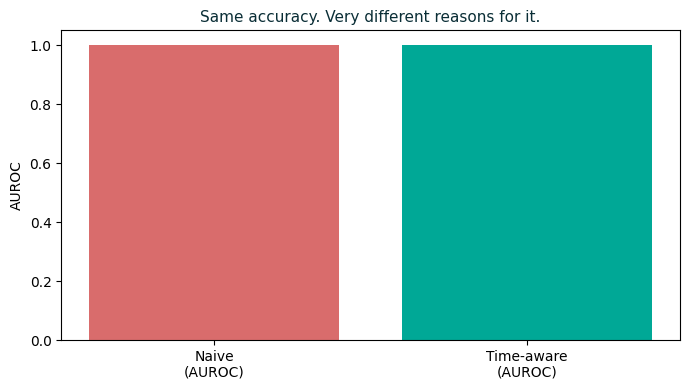


The bar chart looks almost identical. That's the whole point, you cannot tell these models
apart from their headline metric. You can only tell them apart by asking what they are actually leaning on.


In [81]:
fig, ax = plt.subplots(figsize=(7, 4))
labels_ = ["Naive\n(AUROC)", "Time-aware\n(AUROC)"]
scores = [roc_auc_score(yte_naive, proba_naive), roc_auc_score(yte_aware, proba_aware)]
ax.bar(labels_, scores, color=[CORAL, SEAFOAM])
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUROC")
ax.set_title("Same accuracy. Very different reasons for it.", fontsize=11, color=DARK)
fig.tight_layout()
plt.show()

print()
print("The bar chart looks almost identical. That's the whole point, you cannot tell these models")
print("apart from their headline metric. You can only tell them apart by asking what they are actually leaning on.")

That bar chart is the metric that gets published. It's also, on its own, exactly the kind of number this entire block has been arguing you can't trust in isolation. Step 4 showed the shortcut, isolated, failing badly for slow-documenting patients. The real test of the fix isn't whether aggregate AUROC held up, it's whether that same subgroup gap is actually gone once the shortcut is architecturally unavailable.

In [82]:
tier_naive = m.subgroup_recall(pipe_naive, naive_df, y, meta_df, "entanglement_tier")
tier_aware = m.subgroup_recall(pipe_aware, aware_df, y, meta_df, "entanglement_tier")

compare = tier_naive.set_index("group")[["recall"]].rename(columns={"recall": "naive_recall"})
compare["aware_recall"] = tier_aware.set_index("group")["recall"]
compare

,naive_recall,aware_recall
group,,
high,1.0,1.0
low,1.0,1.0
medium,1.0,1.0


Both columns read 1.0, every tier, no gap anywhere, naive and aware alike. This is not the answer you'd get from Step 4 alone. `naive_df` includes real physiology on top of the shortcut, and on this corpus physiology is strong enough that the full model gets every subgroup right regardless, the shortcut's bias never gets the chance to cost anyone recall, it's along for the ride, not doing damage, at least not on this particular sample.

That's precisely why Step 3 built the shortcut in isolation instead of stopping at "check `naive_df`'s subgroup recall and call it a day." A full model's subgroup recall can look perfectly clean while still leaning on something it shouldn't, the bias sitting quietly in a coefficient (Step 2), doing no visible harm only because something else happens to be compensating for it. Change the corpus, change the deployment, change which patients show up, and there's no guarantee that compensation holds. Isolating the shortcut is a stress test for exactly that scenario, and it's the only one of these two checks that actually caught the problem.

Built from real data

This is the figure that anchors this whole tutorial. Asynchronous evidence on the left, becoming interpretable once you impose the structure from the top of this notebook, the possible event window and a true-onset reference line, on the right. Everything in it is real: this patient's actual heart rate, actual lab draw times, actual note charting times.

One thing worth being honest about: the right panel centres on `true_onset_time`, which the model never sees, only `possible_window_start`/`possible_window_end` are available at prediction time. That's a deliberate "answer key" view for you, the model works with the shaded window alone.

This figure's own third panel, a model box and a "what mattered, and when" attribution chart, isn't built here on purpose. Cross-modal, time-aware attribution is Block 3's entire subject, not a preview to spoil.

In [83]:
sid = patient_id  # reuse the same patient from the windowing/soft-label sections above
lrow = labels.set_index("subject_id").loc[sid]
pv_full = vitals[vitals.subject_id == sid]
pl_full = labs[labs.subject_id == sid]
pn_full = notes[notes.subject_id == sid]

span_start = lrow.possible_window_start - pd.Timedelta(hours=8)
span_end = lrow.possible_window_end + pd.Timedelta(hours=8)
pv_w = pv_full[(pv_full.charttime >= span_start) & (pv_full.charttime <= span_end)]
pl_w = pl_full[(pl_full.storetime >= span_start) & (pl_full.storetime <= span_end)]
pn_w = pn_full[(pn_full.storetime >= span_start) & (pn_full.storetime <= span_end)]

window_width_h = (lrow.possible_window_end - lrow.possible_window_start).total_seconds() / 3600
print(f"Patient {sid} with "
      f"{window_width_h:.1f}-hour possible event window:")
print(f"  {len(pv_w)} vitals readings, {len(pl_w)} lab draws, {len(pn_w)} notes charted")
if len(pn_w):
    lag_h = (pn_w.storetime - pn_w.event_charttime).dt.total_seconds() / 3600
    print(f"  Note lag in this window alone: {lag_h.min():.1f}h to {lag_h.max():.1f}h (median {lag_h.median():.1f}h)")

Patient 90000003 with 0.5-hour possible event window:
  66 vitals readings, 12 lab draws, 3 notes charted
  Note lag in this window alone: 3.0h to 8.3h (median 3.8h)


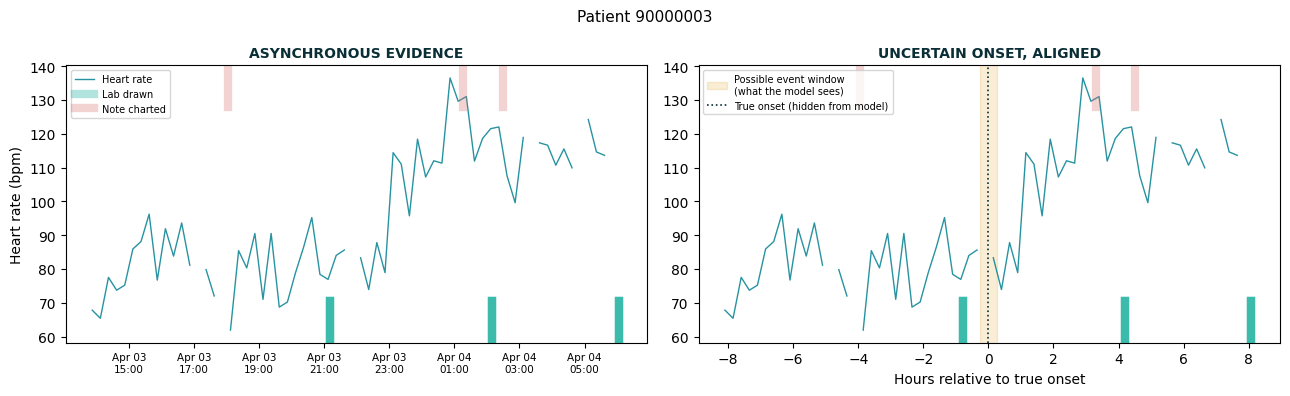

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(pv_w.charttime, pv_w.heartrate, color=TEAL, linewidth=1, alpha=0.85, label="Heart rate")
for i, (_, r) in enumerate(pl_w.iterrows()):
    ax.axvline(r.storetime, color=SEAFOAM, alpha=0.3, linewidth=6, ymax=0.15, label="Lab drawn" if i == 0 else None)
for i, (_, r) in enumerate(pn_w.iterrows()):
    ax.axvline(r.storetime, color=CORAL, alpha=0.3, linewidth=6, ymin=0.85, label="Note charted" if i == 0 else None)
ax.set_title("ASYNCHRONOUS EVIDENCE", fontsize=10, color=DARK, fontweight="bold")
ax.set_ylabel("Heart rate (bpm)")
ax.legend(fontsize=7, loc="upper left")

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
ax.tick_params(axis="x", labelsize=7.5)

ax = axes[1]
t0 = lrow.true_onset_time
rel = lambda t: (t - t0).total_seconds() / 3600
ax.plot(pv_w.charttime.apply(rel), pv_w.heartrate, color=TEAL, linewidth=1, alpha=0.85)
ax.axvspan(rel(lrow.possible_window_start), rel(lrow.possible_window_end), color=AMBER, alpha=0.2,
           label="Possible event window\n(what the model sees)")
ax.axvline(0, color=DARK, linestyle=":", linewidth=1.2, label="True onset (hidden from model)")
for _, r in pl_w.iterrows():
    ax.axvline(rel(r.storetime), color=SEAFOAM, alpha=0.3, linewidth=6, ymax=0.15)
for _, r in pn_w.iterrows():
    ax.axvline(rel(r.storetime), color=CORAL, alpha=0.3, linewidth=6, ymin=0.85)
ax.set_title("UNCERTAIN ONSET, ALIGNED", fontsize=10, color=DARK, fontweight="bold")
ax.set_xlabel("Hours relative to true onset")
ax.legend(fontsize=7, loc="upper left")

fig.suptitle(f"Patient {sid}", fontsize=11)
fig.tight_layout()
plt.show()

Look closely, because the two panels are supposed to look almost identical, and that's the actual point, not an accident. The heart rate line is pixel-for-pixel the same data in both panels, same 164 readings, same shape, same spike near the end. Nothing about the evidence changed between left and right.

What changed is the frame around it. The x-axis shifts from absolute calendar time (left) to hours relative to true onset (right), and the right panel adds two things the left one can't show: the amber band marking the possible event window (30 minutes wide here, 21:43 to 22:13), and the dotted line marking true onset itself, 21:58, a fact the model never actually gets to see, shown here only so you can check the alignment worked.

This is what "alignment" means in this tutorial, and it's worth being precise about it: it's not new data, and it's not a better model. It's the same evidence, re-centred on the moment that actually matters, so a question like "what was happening in the hours around onset" has an answer you can just look at, instead of one you'd have to reconstruct by hand from a timestamp column. If the two panels looked dramatically different, something would have gone wrong, the whole argument is that alignment changes what you can *see*, not what's *there*.

If you only remember one image from this block, this is the one worth keeping: the left panel is what every naive pipeline actually receives, the right panel is what it takes to make that data honest about time.

## Build the report you'd actually hand up

Block 1 ended with a document built for one patient. This block ends with a different kind of document, one built for the *pipeline itself*: the evaluation a document engineer would actually put in front of a manager before anything gets deployed, not a chart, a decision record. `model_report.py` runs all three models fresh, right now, and writes exactly that.

You choose what goes in, same idea as Block 1's `sections` dict, applied here to a model report instead of a patient's chart.

In [85]:
from model_report import render_model_report

sections = dict(
    exec_summary=True,
    model_comparison=True,
    risk_section=True,
    feature_importance=True,
    illustrative_case=True,   # the possible-event-window figure, for one real patient
    document_engineering_case=True,
    recommendation=True,
)

# Write your own review below, in your own words. Add as many entries as you want,
# or leave the list empty and the report skips this section entirely.
custom_sections = [
    {"heading": "My assessment",
     "text": "Write your own conclusion here, based on what you actually saw in the numbers above."},
]

report_path = render_model_report(DATA_DIR, sections=sections, custom_sections=custom_sections,
                                   patient_id=patient_id,  # reuses whichever patient you've been following
                                   save_path=f"{DATA_DIR}model_evaluation_report.pdf", work_dir=DATA_DIR)
print(f"Report saved to: {report_path}")
print("(that's on this Colab machine, not your computer yet, the download cell is right after the next note)")
print("Open it. Every number in it is one you've already seen somewhere above, this just")
print("collects them into the form someone outside this notebook would actually need to see.")

Report saved to: /content/doceng26-pulse-and-paper/datamodel_evaluation_report.pdf
(that's on this Colab machine, not your computer yet, the download cell is right after the next note)
Open it. Every number in it is one you've already seen somewhere above, this just
collects them into the form someone outside this notebook would actually need to see.


Notice what `document_engineering_case` is doing in that dict, and it is an optional section. Turn it off and you get a clean, purely technical model comparison, AUROC, Brier, subgroup recall, feature weights, nothing about representation or document engineering at all. Turn it on, and the report makes the actual argument this entire block has been building: the fix was never a better model, it was a better-engineered feature set, and that distinction belongs in the same document as the numbers, not as separate context someone has to already know to appreciate.

If you're running this in Colab, the cell below downloads it.

In [86]:
try:
    from google.colab import files
    files.download(report_path)
    print(f"Downloading: {report_path.split('/')[-1]}")
    print("This should land in your browser's default download location, usually your computer's")
    print("Downloads folder, unless you've set your browser to ask each time or save somewhere else.")
except ImportError:
    print("Not running in Colab, your report is already saved locally at the path printed above.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: datamodel_evaluation_report.pdf
This should land in your browser's default download location, usually your computer's
Downloads folder, unless you've set your browser to ask each time or save somewhere else.


## Your turn

A few things worth trying:

- **Train `aware_df` against soft labels instead of the hard `outcome` column.** `soft_event_label()` is fully built and unused in the current pipeline, that's not an oversight, it's an exercise. You'd need a soft target per prediction time rather than one outcome per patient, worth sketching on paper before you code it.
- Change `PREDICTION_OFFSET_HOURS` in `models.py` (try 3, try 12) and re-run from Step 3. Watch how the shortcut's own predictive power and its subgroup gap both shift, earlier means less documentation has caught up for *anyone*; later means slow-charting patients start to catch up too, and the gap should narrow.
- Try `subgroup_recall(..., "socioeconomic_context")` in Step 4 instead of population context, an axis about resourcing, not diagnosis.
- Look back at Step 2's coefficient table for the naive model. If you increase note-related noise in the generator (more caregiver notes, longer lag), does `has_event_note_naive`'s coefficient grow?
- Pick a different `patient_id` at the top of the "Three things" section (any `outcome == 1` subject works for the soft-label and Figure 1 cells) and watch how differently the story reads for a low-entanglement vs. high-entanglement patient.

## What you built

- Event-centred windowing, soft probabilistic labelling under onset uncertainty, and structured missingness, the three strategies this tutorial is built around, each used by hand on real patient data before any model existed
- A naive model that looked excellent and was quietly leaning on documentation speed anyway
- Proof, isolated and measured, that documentation timing alone is real signal, and unevenly available signal
- A subgroup breakdown showing exactly who that unevenness hurts, not as an assertion, as a number you computed
- A time-aware model with equivalent accuracy and no architectural path to that same bias
- This tutorial's own Figure 1, rebuilt from a real patient rather than a diagram

Block 3 takes this further: instead of just knowing the time-aware model doesn't lean on documentation speed, you'll build the tools to show *what it does lean on, and when that evidence became available*, and use a mismatch between those two things as an audit signal in its own right, the third panel this block deliberately left for you to earn.